In [1]:
from pathlib import Path
import pickle

import pandas as pd
import numpy as np
import inspect
import xarray as xr

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics, get_tester
from neuralhydrology.utils.config import Config
import neuralhydrology.modelzoo
from neuralhydrology.nh_run import start_run, eval_run, finetune
from neuralhydrology.evaluation.prob_metrics import run_probabilistic_evaluation

In [ ]:
# This block ensures the code inside only runs when the script is executed directly
if __name__ == '__main__':

    # by default we assume that you have at least one CUDA-capable NVIDIA GPU or MacOS with Metal
    # support
    if torch.cuda.is_available() or torch.backends.mps.is_available():
        start_run(config_file=Path("1_basin.yml"))

    # fall back to CPU-only mode
    else:
        start_run(config_file=Path("1_basin.yml"), gpu=-1)

2025-11-13 06:05:15,975: Logging to d:\github\neuralhydrology\neuralhydrology\own\operational_forecast\runs\test_run_1311_060515\output.log initialized.
2025-11-13 06:05:15,975: ### Folder structure created at d:\github\neuralhydrology\neuralhydrology\own\operational_forecast\runs\test_run_1311_060515
2025-11-13 06:05:15,975: ### Run configurations for test_run
2025-11-13 06:05:15,975: experiment_name: test_run
2025-11-13 06:05:15,975: use_frequencies: ['2W-MON', '4W-MON']
2025-11-13 06:05:15,975: train_basin_file: 1_basin.txt
2025-11-13 06:05:15,975: validation_basin_file: 1_basin.txt
2025-11-13 06:05:15,975: test_basin_file: 1_basin.txt
2025-11-13 06:05:15,975: train_start_date: 1999-09-27 00:00:00
2025-11-13 06:05:15,975: train_end_date: 2008-08-31 00:00:00
2025-11-13 06:05:15,975: validation_start_date: 1996-09-30 00:00:00
2025-11-13 06:05:15,975: validation_end_date: 1999-09-12 00:00:00
2025-11-13 06:05:15,975: test_start_date: 1989-10-02 00:00:00
2025-11-13 06:05:15,975: test_end

2025-11-13 13:28:23,354: Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\Workstation\anaconda3\envs\neuralhydrology\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\Workstation\anaconda3\envs\neuralhydrology\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host
2025-11-13 13:28:23,354: Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\Workstation\anaconda3\envs\neuralhydrology\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\Workstation\anaconda3\envs\neuralhydrology\lib\asyncio\selector_

In [4]:
run_dir = Path("runs/test_run_1311_060515")
eval_run(run_dir=run_dir, period="test")

d:\github\neuralhydrology\neuralhydrology\neuralhydrology\evaluation\tester.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(weigh

# Evaluation:   0%|          | 0/516 [00:00<?, ?it/s]DEBUG: Creating data variables using UNCERTAINTY logic.
DEBUG: Creating data variables using UNCERTAINTY logic.
# Evaluation:   0%|          | 1/516 [00:01<13:35,  1.58s/it]DEBUG: Creating data variables using UNCERTAINTY logic.
DEBUG: Creating data variables using UNCERTAINTY logic.
# Evaluation:   0%|          | 2/516 [00:01<06:56,  1.23it/s]DEBUG: Creating data variables using UNCERTAINTY logic.
DEBUG: Creating data variables using UNCERTAINTY logic.
# Evaluation:   1%|          | 3/516 [00:02<04:54,  1.74it/s]DEBUG: Creating data variables using UNCERTAINTY logic.
DEBUG: Creating data variables using UNCERTAINTY logic.
# Evaluation:   1%|          | 4/516 [00:02<03:48,  2.24it/s]DEBUG: Creating data variables using UNCERTAINTY logic.
DEBUG: Creating data variables using UNCERTAINTY logic.
# Evaluation:   1%|          | 5/516 [00:02<03:17,  2.59it/s]DEBUG: Creating data variables using UNCERTAINTY logic.
DEBUG: Creating data varia

In [5]:
with open(run_dir / "test" / "model_epoch020" / "test_results.p", "rb") as fp:
    results = pickle.load(fp)
    
results.keys()

dict_keys(['01022500', '01031500', '01047000', '01052500', '01054200', '01055000', '01057000', '01073000', '01078000', '01123000', '01134500', '01137500', '01139000', '01139800', '01142500', '01144000', '01162500', '01169000', '01170100', '01181000', '01187300', '01195100', '01333000', '01350000', '01350080', '01350140', '01365000', '01411300', '01413500', '01414500', '01415000', '01423000', '01434025', '01435000', '01439500', '01440000', '01440400', '01451800', '01466500', '01484100', '01487000', '01491000', '01510000', '01516500', '01518862', '01532000', '01539000', '01542810', '01543000', '01543500', '01544500', '01545600', '01547700', '01548500', '01549500', '01550000', '01552000', '01552500', '01557500', '01567500', '01568000', '01580000', '01583500', '01586610', '01591400', '01594950', '01596500', '01605500', '01606500', '01632000', '01632900', '01634500', '01638480', '01639500', '01644000', '01664000', '01666500', '01667500', '01669000', '01669520', '02011400', '02013000', '0201

In [10]:
# Load validation results from the last epoch
df = pd.read_csv(run_dir / "validation" / "model_epoch020" / "validation_metrics.csv", dtype={'basin': str})
df = df.set_index('basin')

print("Available columns are:")
print(df.columns)

# Compute the median NSE from all basins, where discharge observations are available for that period
print(f"Median NSE of the validation period {df['QObs(mm/day)_2W_NSE_2W-MON'].median():.3f}")

Available columns are:
Index(['QObs(mm/day)_4W_NSE_2W-MON', 'QObs(mm/day)_2W_NSE_2W-MON',
       'QObs(mm/day)_4W_NSE_4W-MON', 'QObs(mm/day)_2W_NSE_4W-MON'],
      dtype='object')
Median NSE of the validation period 0.564


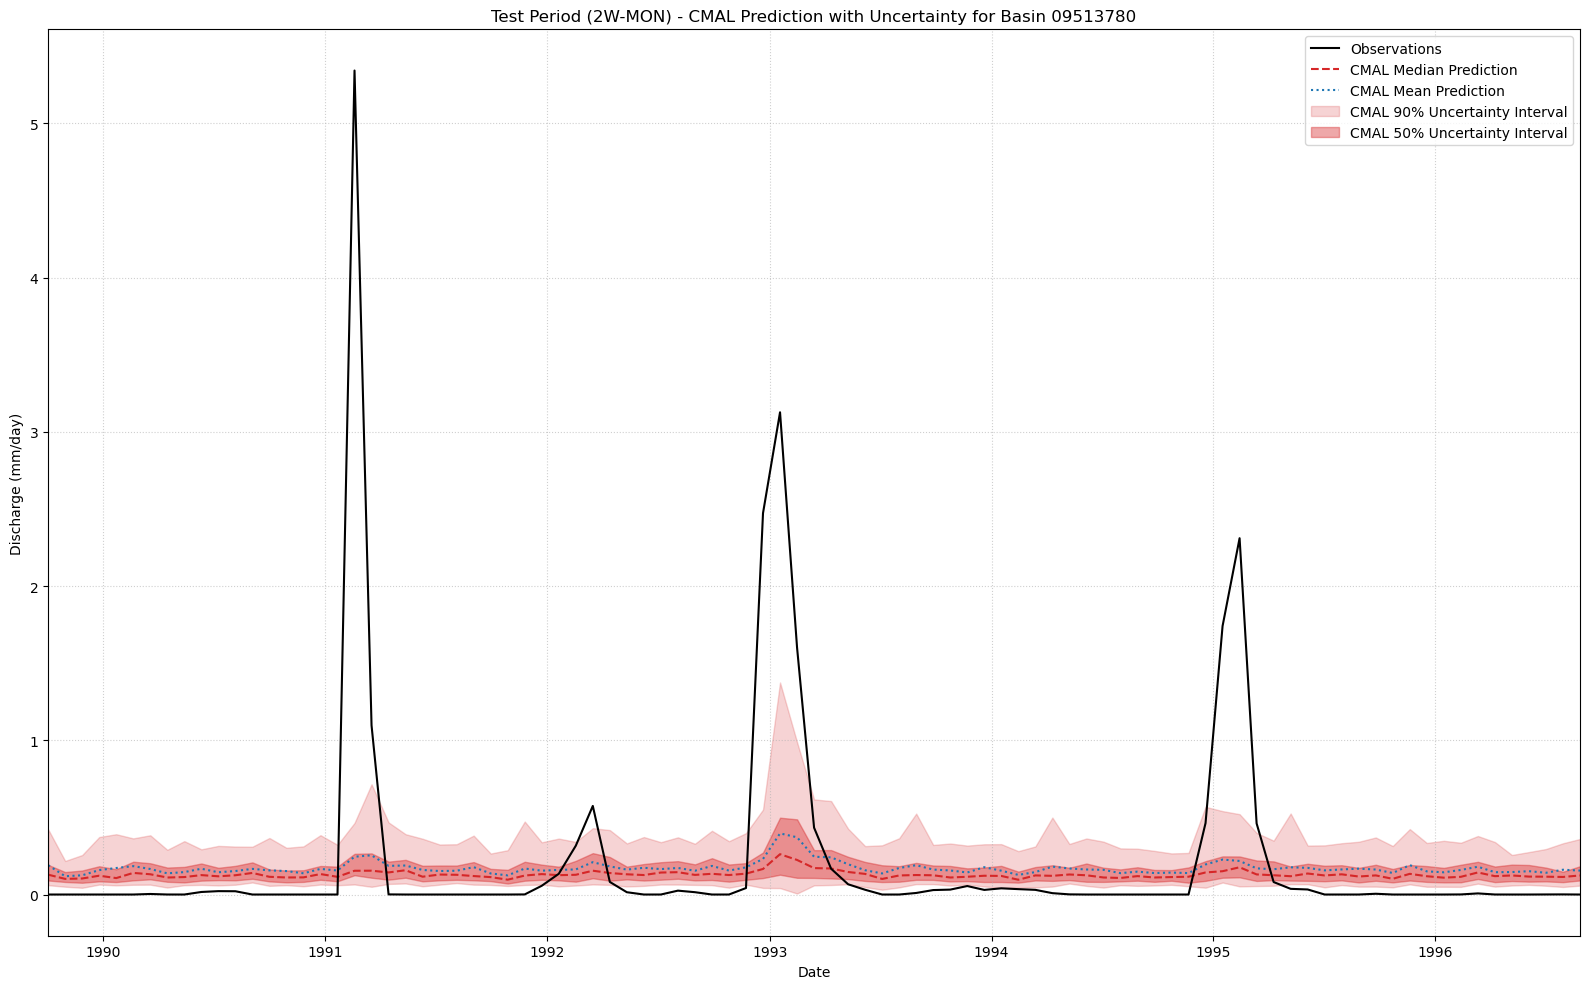

In [40]:
basin_id = '09513780'
freq = '2W-MON'
if freq == '4W-MON':
    target_variable = 'QObs(mm/day)_4W'
elif freq == '2W-MON':
    target_variable = 'QObs(mm/day)_2W'
else:
    raise ValueError(f"Invalid frequency '{freq}'. Choose '4W-MON' or '2W-MON'.")

# --- DATA EXTRACTION (Same as before) ---
try:
    results_xr = results[basin_id][freq]['xr']
except KeyError:
    print(f"ERROR: Could not find results for basin '{basin_id}' and frequency '{freq}'.")
    raise

qobs = results_xr[f'{target_variable}_obs']
qsim_with_samples = results_xr[f'{target_variable}_sim']

# --- CALCULATE QUANTILES (Same as before) ---
median_sim = qsim_with_samples.quantile(0.5, dim='samples')
q25 = qsim_with_samples.quantile(0.25, dim='samples')
q75 = qsim_with_samples.quantile(0.75, dim='samples')
q05 = qsim_with_samples.quantile(0.05, dim='samples')
q95 = qsim_with_samples.quantile(0.95, dim='samples')
mean_sim = qsim_with_samples.mean(dim='samples')


# --- 4. Plotting with Matplotlib for Uncertainty (WITH FIXES) ---
fig, ax = plt.subplots(figsize=(16, 10))

# --- FIX: Add .squeeze() to ensure all arrays are 1D ---
ax.plot(qobs['date'].values, qobs.values.squeeze(), color='black', label='Observations', linewidth=1.5, zorder=5)

ax.plot(median_sim['date'].values, median_sim.values.squeeze(), color='#d62728', linestyle='--', label='CMAL Median Prediction', linewidth=1.5)
ax.plot(mean_sim['date'].values, mean_sim.values.squeeze(), color='#1f77b4', linestyle=':', label='CMAL Mean Prediction', linewidth=1.5)

ax.fill_between(
    q05['date'].values,
    q05.values.squeeze(),         # <-- FIX HERE
    q95.values.squeeze(),         # <-- FIX HERE
    color='#d62728',
    alpha=0.2,
    label='CMAL 90% Uncertainty Interval'
)

ax.fill_between(
    q25['date'].values,
    q25.values.squeeze(),         # <-- FIX HERE
    q75.values.squeeze(),         # <-- FIX HERE
    color='#d62728',
    alpha=0.4,
    label='CMAL 50% Uncertainty Interval'
)

# --- Formatting (Same as before) ---
ax.set_ylabel("Discharge (mm/day)")
ax.set_xlabel("Date")
ax.set_title(f"Test Period ({freq}) - CMAL Prediction with Uncertainty for Basin {basin_id}")
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim([qobs['date'].values.min(), qobs['date'].values.max()])
plt.tight_layout()
plt.show()

In [15]:
qobs_1d = qobs.squeeze()
mean_sim_1d = mean_sim.squeeze()

# Calculate all metrics for the median prediction
values = metrics.calculate_all_metrics(qobs_1d, mean_sim_1d)

# Print the calculated metrics
print("\nMetrics for CMAL Median Prediction:")
for key, val in values.items():
    print(f"{key}: {val:.3f}")


Metrics for CMAL Median Prediction:
NSE: 0.378
MSE: 3.871
RMSE: 1.968
KGE: 0.347
Alpha-NSE: 0.457
Beta-KGE: 0.919
Beta-NSE: -0.066
Pearson-r: 0.647
FHV: -70.392
FMS: -28.580
FLV: 64.405
Peak-Timing: nan
Peak-MAPE: 76.351


In [28]:
# Select a random basins from the lower 50% of the NSE distribution
basin = df.loc[df["QObs(mm/day)_2W_NSE_2W-MON"] < df["QObs(mm/day)_2W_NSE_2W-MON"].median()].sample(n=1).index[0]

print(f"Selected basin: {basin} with an NSE of {df.loc[df.index == basin, 'QObs(mm/day)_2W_NSE_2W-MON'].values[0]:.3f}")

Selected basin: 09513780 with an NSE of 0.025


In [29]:
# Add the path to the pre-trained model to the finetune config
with open("finetune.yml", "a") as fp:
    fp.write(f"\nbase_run_dir: {run_dir.absolute()}")
    
# Create a basin file with the basin we selected above
with open("finetune_basin.txt", "w") as fp:
    fp.write(basin)

In [31]:
finetune(Path("finetune.yml"))

2025-11-14 01:39:34,698: Logging to d:\github\neuralhydrology\neuralhydrology\own\operational_forecast\runs\mtslstmcmal_basins_finetuned_1411_013934\output.log initialized.
2025-11-14 01:39:34,700: ### Folder structure created at d:\github\neuralhydrology\neuralhydrology\own\operational_forecast\runs\mtslstmcmal_basins_finetuned_1411_013934
2025-11-14 01:39:34,700: ### Start finetuning with pretrained model stored in d:\github\neuralhydrology\neuralhydrology\own\operational_forecast\runs\test_run_1311_060515
2025-11-14 01:39:34,700: ### Run configurations for mtslstmcmal_basins_finetuned
2025-11-14 01:39:34,700: batch_size: 256
2025-11-14 01:39:34,700: clip_gradient_norm: 1
2025-11-14 01:39:34,700: clip_targets_to_zero: ['QObs(mm/day)_4W', 'QObs(mm/day)_2W']
2025-11-14 01:39:34,700: commit_hash: 2900613
2025-11-14 01:39:34,705: data_dir: ..\..\data\CAMELS_US
2025-11-14 01:39:34,705: dataset: camels_preprocessed
2025-11-14 01:39:34,706: device: cuda:0
2025-11-14 01:39:34,707: dynamic_in

d:\github\neuralhydrology\neuralhydrology\neuralhydrology\training\basetrainer.py:161: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(st

# Epoch 1: 100%|██████████| 1/1 [00:03<00:00,  3.21s/it, Loss: -3.2212]
2025-11-14 01:39:38,292: Epoch 1 average loss: avg_loss: -3.22564, avg_tie_frequencies_cmal: 0.00441, avg_total_loss: -3.22123
2025-11-14 01:39:38,305: --- Epoch 2 starts ---
2025-11-14 01:39:38,305: Learning rate keys in config: [0]
2025-11-14 01:39:38,306: Epoch 2 not found in config.learning_rate.keys(). LR will be handled by scheduler if applicable.
2025-11-14 01:39:38,307: DEBUG: Reached scheduler check for epoch 2. lr_overridden_this_epoch is False
2025-11-14 01:39:38,307: Before scheduler step: lr_overridden_this_epoch = False
# Epoch 2: 100%|██████████| 1/1 [00:03<00:00,  3.57s/it, Loss: -3.2967]
2025-11-14 01:39:41,880: Epoch 2 average loss: avg_loss: -3.30048, avg_tie_frequencies_cmal: 0.00380, avg_total_loss: -3.29668
2025-11-14 01:39:41,887: --- Epoch 3 starts ---
2025-11-14 01:39:41,887: Learning rate keys in config: [0]
2025-11-14 01:39:41,889: Epoch 3 not found in config.learning_rate.keys(). LR will

Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "c:\Users\Workstation\anaconda3\envs\neuralhydrology\lib\multiprocessing\queues.py", line 239, in _feed
Exception ignored in: <function _ConnectionBase.__del__ at 0x0000018E37D739A0>
Traceback (most recent call last):
  File "c:\Users\Workstation\anaconda3\envs\neuralhydrology\lib\multiprocessing\connection.py", line 132, in __del__
    reader_close()
  File "c:\Users\Workstation\anaconda3\envs\neuralhydrology\lib\multiprocessing\connection.py", line 177, in close
    self._close()
  File "c:\Users\Workstation\anaconda3\envs\neuralhydrology\lib\multiprocessing\connection.py", line 277, in _close
    self._close()
  File "c:\Users\Workstation\anaconda3\envs\neuralhydrology\lib\multiprocessing\connection.py", line 277, in _close
    _CloseHandle(self._handle)
OSError: [WinError 6] The handle is invalid
    _CloseHandle(self._handle)
OSError: [WinError 6] The handle is invalid

During handling of the above ex

DEBUG: Creating data variables using UNCERTAINTY logic.
DEBUG: Creating data variables using UNCERTAINTY logic.
# Validation: 100%|██████████| 1/1 [00:05<00:00,  5.48s/it]
2025-11-14 01:41:44,282: Stored metrics at d:\github\neuralhydrology\neuralhydrology\own\operational_forecast\runs\mtslstmcmal_basins_finetuned_1411_013934\validation\model_epoch030\validation_metrics.csv
2025-11-14 01:41:44,283: Stored results at d:\github\neuralhydrology\neuralhydrology\own\operational_forecast\runs\mtslstmcmal_basins_finetuned_1411_013934\validation\model_epoch030\validation_results.p
2025-11-14 01:41:44,285: Before scheduler step: lr_overridden_this_epoch = False
2025-11-14 01:41:44,286: ReduceLROnPlateau stepped for epoch 30.
2025-11-14 01:41:44,286: Scheduler state after step - best: 3.316450834274292
2025-11-14 01:41:44,287: Scheduler state after step - num_bad_epochs: 1
2025-11-14 01:41:44,288: Current Learning Rate: 2.5e-05
2025-11-14 01:41:44,289: Current Learning Rate: 2.5e-05
2025-11-14 0

In [34]:
finetune_dir = Path("runs/mtslstmcmal_basins_finetuned_1411_013934")
eval_run(finetune_dir, period="test")

2025-11-14 01:47:14,431: No specific hidden size for frequencies are specified. Same hidden size is used for all.
2025-11-14 01:47:14,443: Using the model weights from runs\mtslstmcmal_basins_finetuned_1411_013934\model_epoch050.pt


d:\github\neuralhydrology\neuralhydrology\neuralhydrology\evaluation\tester.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(weigh

# Evaluation:   0%|          | 0/1 [00:00<?, ?it/s]DEBUG: Creating data variables using UNCERTAINTY logic.
DEBUG: Creating data variables using UNCERTAINTY logic.
# Evaluation: 100%|██████████| 1/1 [00:00<00:00,  4.38it/s]
2025-11-14 01:47:14,686: Stored metrics at runs\mtslstmcmal_basins_finetuned_1411_013934\test\model_epoch050\test_metrics.csv
2025-11-14 01:47:14,687: Stored results at runs\mtslstmcmal_basins_finetuned_1411_013934\test\model_epoch050\test_results.p


In [35]:
# load test results of the base run
df_pretrained = pd.read_csv(run_dir / "test/model_epoch020/test_metrics.csv", dtype={'basin': str})
df_pretrained = df_pretrained.set_index("basin")
    
# load test results of the finetuned model
df_finetuned = pd.read_csv(finetune_dir / "test/model_epoch050/test_metrics.csv", dtype={'basin': str})
df_finetuned = df_finetuned.set_index("basin")
    
# extract basin performance
base_model_nse = df_pretrained.loc[df_pretrained.index == basin, "QObs(mm/day)_2W_NSE_2W-MON"].values[0]
finetune_nse = df_finetuned.loc[df_finetuned.index == basin, "QObs(mm/day)_2W_NSE_2W-MON"].values[0]
print(f"Basin {basin} base model performance: {base_model_nse:.3f}")
print(f"Performance after finetuning: {finetune_nse:.3f}")

Basin 09513780 base model performance: 0.064
Performance after finetuning: 0.051


Generating uncertainty plots for basin 09513780 at 2W-MON frequency...
Found matching target variable: QObs(mm/day)_2W

Using 'percentile_plot' (full hydrograph)...


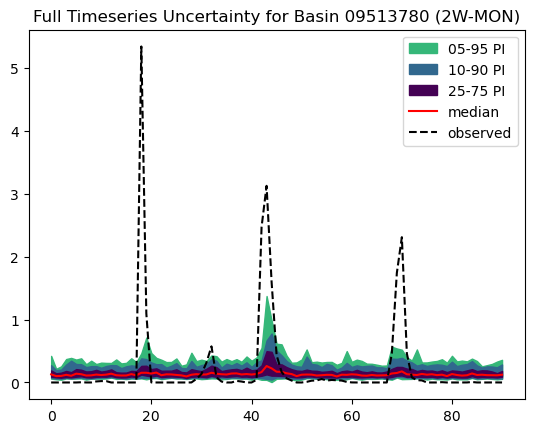

In [39]:
from neuralhydrology.evaluation.plots import uncertainty_plot, percentile_plot

try:
    cfg = Config(run_dir / "config.yml")
except (NameError, FileNotFoundError):
    raise RuntimeError("The 'run_dir' variable is not defined or 'config.yml' is missing.")

# --- 3. Configuration (WITH FIX) ---
basin_id = '09513780'       # The basin ID you are analyzing
freq = '2W-MON'               # Choose the frequency to plot

# --- THIS IS THE CORRECTED LOGIC ---
try:
    # Get the base frequency (e.g., '2W-MON' -> '2W')
    base_freq = freq.split('-')[0]
    
    # Find the target variable that contains the base frequency
    target_variable = [v for v in cfg.target_variables if base_freq in v][0]
except IndexError:
    raise ValueError(f"Could not find a target variable for frequency '{freq}' in your config's target_variables list.")
# --- END OF CORRECTION ---

# Define the variable names to extract from the results xarray
obs_var_name = f"{target_variable}_obs"
samples_var_name = f"{target_variable}_sim"

print(f"Generating uncertainty plots for basin {basin_id} at {freq} frequency...")
print(f"Found matching target variable: {target_variable}")

# --- 4. Data Extraction and Reshaping (Same as before) ---
try:
    xr_data = results[basin_id][freq]['xr']
    
    if samples_var_name not in xr_data:
        raise KeyError(f"The samples variable '{samples_var_name}' was not found!")

    obs_data_np = xr_data[obs_var_name].values
    samples_data_np = xr_data[samples_var_name].values
    
    # Reshape observations: Add a 'feature' dimension
    if obs_data_np.ndim == 1:
        y_obs_reshaped = np.expand_dims(obs_data_np, axis=1) 
    else:
        y_obs_reshaped = obs_data_np

    # Reshape samples: Add a 'feature' dimension
    if samples_data_np.ndim == 2:
        y_samples_reshaped = np.expand_dims(samples_data_np, axis=1)
    else:
        y_samples_reshaped = samples_data_np
        
except KeyError as e:
    print(f"CRITICAL ERROR: {e}")
    print("\nSomething went wrong during data extraction.")
    print(f"Available variables in the results file are: {list(xr_data.keys())}")
    raise

# --- 5. Call the Official Plotting Functions (Same as before) ---
#print("\nUsing 'uncertainty_plot' (reliability + hydrograph zoom-in)...")
#fig, axes = uncertainty_plot(y=y_obs_reshaped,
#                           y_hat=y_samples_reshaped,
#                           title=f"Uncertainty for Basin {basin_id} ({freq})")
#plt.show()

print("\nUsing 'percentile_plot' (full hydrograph)...")
fig2, ax2 = percentile_plot(y=y_obs_reshaped,
                            y_hat=y_samples_reshaped,
                            title=f"Full Timeseries Uncertainty for Basin {basin_id} ({freq})")
plt.show()

      Running Probabilistic Analysis for Timescale: 2W-MON      
Performing probabilistic evaluation on 91 timesteps with 100 samples each.

Calculating reliability...
Calculating resolution (sharpness)...


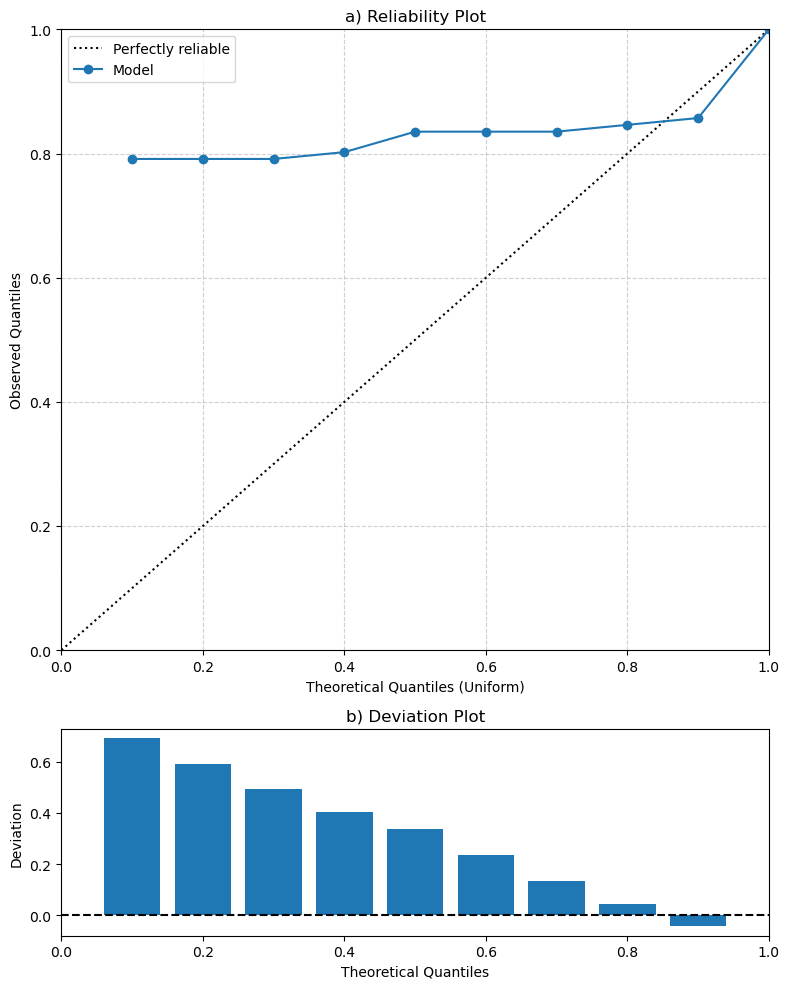


Resolution Metrics (lower is better):
  - mean_std_dev: 0.1512
  - mean_interquartile_range: 0.1117
  - mean_interdecile_range: 0.2376
      Running Probabilistic Analysis for Timescale: 4W-MON      
Performing probabilistic evaluation on 91 timesteps with 100 samples each.

Calculating reliability...
Calculating resolution (sharpness)...


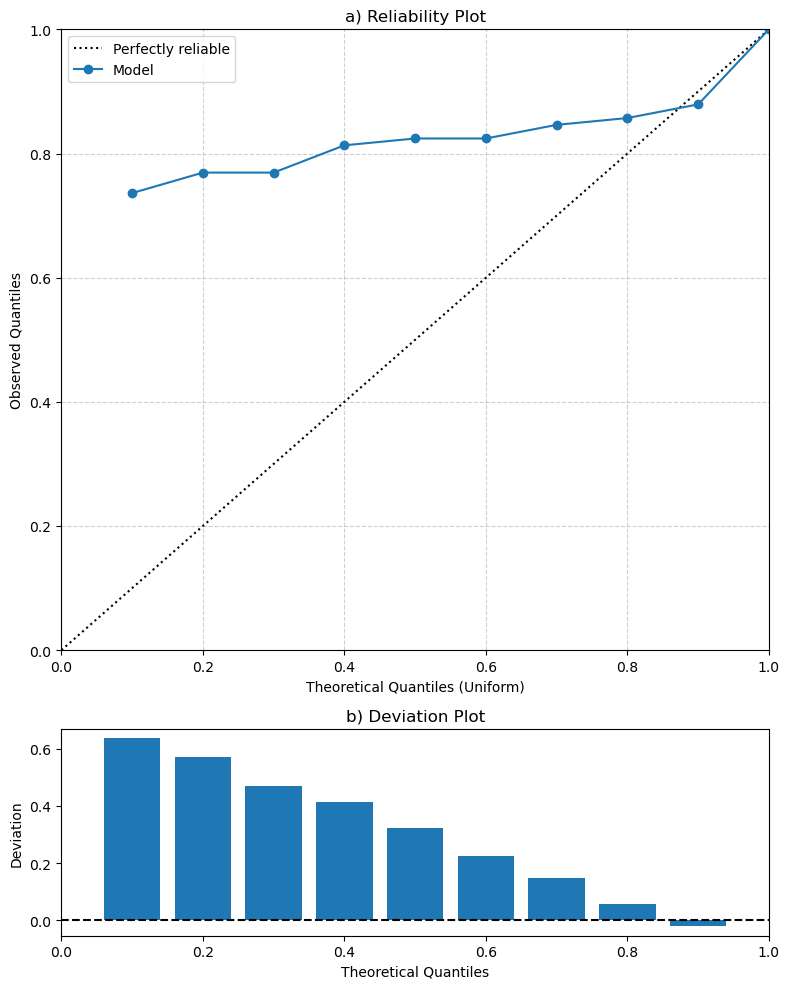


Resolution Metrics (lower is better):
  - mean_std_dev: 0.1638
  - mean_interquartile_range: 0.1513
  - mean_interdecile_range: 0.2921


In [41]:
# Make sure 'run_dir' is pointing to your correctly evaluated run folder
try:
    cfg = Config(run_dir / "config.yml")
except NameError:
    raise NameError("The 'run_dir' variable is not defined. Please define it before this cell.")

# --- 3. Configuration ---
basin_id = '09513780'       # The basin ID you are analyzing
target_variable = cfg.target_variables[0] # Dynamically get target from config

# Define the variable names to look for in the results file
obs_var_name = f"{target_variable}_obs"

# ######################################################################
# ################         THIS IS THE CRITICAL FIX         ##############
# The UncertaintyTester saves samples under the '_sim' key.
samples_var_name = f"{target_variable}_sim"
# ######################################################################
# ######################################################################


# --- 4. Loop through frequencies and run analysis ---
if basin_id not in results:
    raise ValueError(f"Basin {basin_id} not found in results. Available basins: {list(results.keys())}")

for frequency in cfg.use_frequencies: 
    print("======================================================================")
    print(f"      Running Probabilistic Analysis for Timescale: {frequency}      ")
    print("======================================================================")

    try:
        # Extract the xarray Dataset for the current frequency
        xr_data = results[basin_id][frequency]['xr']
        
        # Extract observations and simulation samples using the correct variable names
        obs_data_multidim = xr_data[obs_var_name].values
        sim_samples_multidim = xr_data[samples_var_name].values

        # --- Data Reshaping to get 1D (obs) and 2D (samples) arrays ---
        # Flatten all time dimensions into a single long timeseries
        obs_data_flat = obs_data_multidim.flatten()
        
        # Reshape samples to (total_timesteps, n_samples)
        num_samples = sim_samples_multidim.shape[-1]
        sim_samples_reshaped = sim_samples_multidim.reshape(-1, num_samples)
            
        # --- Handle NaNs ---
        valid_indices = ~np.isnan(obs_data_flat)
        if not np.all(valid_indices):
            print(f"Warning: Found and removed {np.sum(~valid_indices)} NaN values in observations.")
            obs_data = obs_data_flat[valid_indices]
            sim_samples = sim_samples_reshaped[valid_indices, :]
        else:
            obs_data = obs_data_flat
            sim_samples = sim_samples_reshaped

        # --- Run the analysis ---
        probabilistic_results = run_probabilistic_evaluation(obs=obs_data, sim_samples=sim_samples)

    except KeyError as e:
        print(f"\nCould not run analysis for frequency '{frequency}'.")
        # Update the error message to be more informative
        print(f"A required data variable was not found. Tried to find '{obs_var_name}' and '{samples_var_name}'.")
        print(f"Available variables are: {list(xr_data.keys())}\n")
    except Exception as e:
        print(f"\nAn unexpected error occurred for frequency '{frequency}': {e}\n")